# Integration

In order to understand the problem better, I will attempt to solve the system of equations using the recommended python libraries.

In [7]:
import numpy as np # this supports most of the math operations.
import matplotlib.pyplot as plt # This show a graph
from scipy.integrate import solve_ivp # This is our integrator.

## System of differential equations

Let's recreate the system of differential equations given in the problem statement:

In [8]:
def get_ode(t, y,mu=0.5,q=2,p0=1e-7,X0=0.1,c1=5,c2=12):
  '''
    Returns the value of an ODE at a given point and a given time.
    t: The time.
    y: A tuple describing a point on both equations.
    mu: Bacterial growth rate
    q: Lactic acid production rate per bacterium 
    p0: Initial lactic acid concentration
    X0: Initial bacterial concentration 
    c1: A constant.
    c2: Another constant.

    This is python a representation of the formulae described at rationale.md and manual-integration.md
  '''
  X, p = y
  pH = -np.log10(max(p, 1e-14)) 
  sigma = 1.0 / (1.0 + np.exp(-c2 * (pH - c1)))
  dX_dt = mu * X * sigma
  dp_dt = (10**q) * X * sigma
  return [dX_dt, dp_dt]

## Integrator

As shown in [manual-integration.md](manual-integration.md), the system of equations can be solved using numerical integration methods. In this case, we will use the `solve_ivp` function from the `scipy.integrate` library to solve the system of equations.

In [9]:
def integrate(
    t0=0,
    t=24,
    samples=1000,
    method='RK45',
    X0=10e6,
    p0=10e-6,
    mu = 0.5 ,
    q = -2.0,
    c1 = 5.0,
    c2 = 12.0
):
    '''
        Integrates the equation system for cream cheese, and returns array of 
        arrays including the rate of change: time, X values, P values, and pH values.
    '''
    t_span = (t0,t)  
    t_eval = np.linspace(t_span[0], t_span[1],samples)
    initial_state = [X0, p0]
    solution = solve_ivp(
        get_ode, 
        t_span, 
        initial_state, 
        t_eval=t_eval, 
        method=method
    )
    t_steps = solution.t
    X_values = solution.y[0]
    p_values = solution.y[1]
    pH_values = -np.log10(p_values)
    def get_sigma(pH):
        sigma = 1.0 / (1.0 + np.exp(-c2 * (pH - c1)))
        return sigma
    sigma_values = [get_sigma(pH) for pH in pH_values]
    return [t_steps,X_values,p_values,pH_values,sigma_values]

## Plotting

To visualize the results of the integration, we will use the `matplotlib` library to plot the solutions of the system of equations over time. This will allow us to see how the variables change and interact with each other throughout the fermentation process.

In [10]:

def plot(series):
  fig, ax1 = plt.subplots(figsize=(10, 5))

  color = 'tab:blue'
  ax1.set_xlabel('Time (t)')
  ax1.set_ylabel('Bacterial Concentration X(t)', color=color)
  ax1.plot(series[0][1:], series[1][1:], color=color, linewidth=2, label='Bacteria (X)')
  ax1.tick_params(axis='y', labelcolor=color)

  # This plot p(t) has been omitted as it has the same curve as X(p)
  '''
  ax2 = ax1.twinx()  
  color = 'tab:red'
  ax2.set_ylabel('p(t)', color=color)
  ax2.plot(series[0][1:], series[2][1:], color=color, linewidth=2, linestyle='--')
  ax2.tick_params(axis='y', labelcolor=color)
  '''

  ax3 = ax1.twinx()  
  color = 'tab:orange'
  ax3.set_ylabel('pH(t)', color=color)
  ax3.plot(series[0][1:], series[3][1:], color=color, linewidth=2, linestyle='--')
  ax3.tick_params(axis='y', labelcolor=color)

  ax4 = ax1.twinx()  
  color = 'tab:green'
  ax4.set_ylabel('s(pH)', color=color)
  ax4.plot(series[0][1:], series[4][1:], color=color, linewidth=2, linestyle='--')
  ax4.tick_params(axis='y', labelcolor=color)

  plt.title('Bacterial Growth and Media Acidification Over Time')
  fig.tight_layout()
  plt.show()

# Playground

With the integration and plotting set up, we can now run a test to see how the 
system behaves over a specified time period. This will help us understand the 
dynamics of the fermentation process and identify any interesting patterns or 
behaviors in the variables.

In [13]:
# Modify this values to test the model
X0 = 10e6
p0 = 10e-6
mu = 1
q = -15

X0:10000000.0
p0:1e-05
mu:1
q:-13


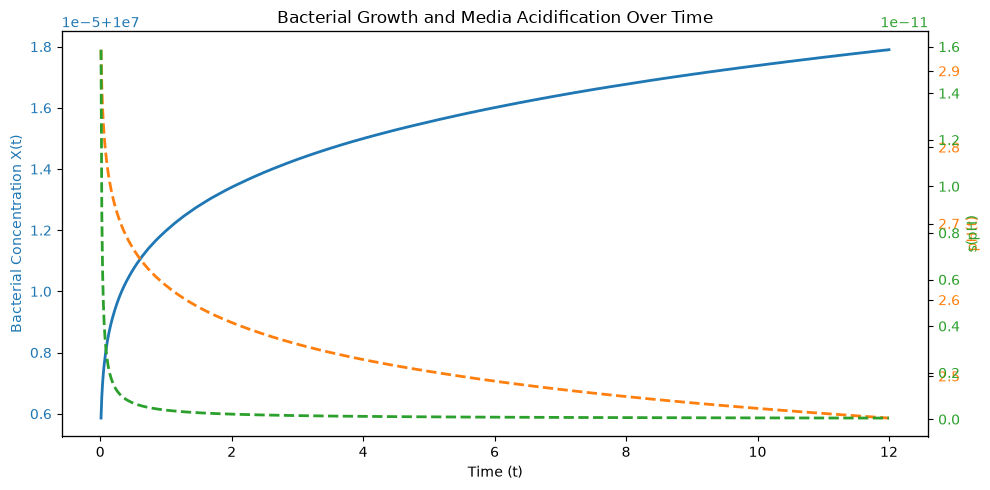

In [14]:
print(f"X0:{X0}")
print(f"p0:{p0}")
print(f"mu:{mu}")
print(f"q:{q}")
series = integrate(
    0,
    12,
    1000,
   'RK45',
    X0,
    p0,
    mu,
    q
)
plot(series)

## Conclusion

Results makes sense, the plotting show the expected growth on bacterial 
concentration and growth in lactic acid concentration, parallel to the decrease 
on Ph values and sigma values which aligns with the acidity increase.

With this we can start thinking on how to build a user interface that allows the 
user to interact with the model and explore different scenarios, and also a 
system to store models.